In [24]:
import torch
from matplotlib import pyplot as plt
import numpy as np

In [48]:
def get_avg_out_of_files(files):
    results = {'wer':[], 'individual_wers':{}, 'recording_ids':[]}
    for i, file in enumerate(files):
        cur_file = torch.load(file)
        results['wer'].append(cur_file['wer'])
        for key in cur_file['individual_wers']:
            if key not in results['individual_wers']:
                results['individual_wers'][key] = []
            results['individual_wers'][key].append(cur_file['individual_wers'][key])
        if i==0:
            results['recording_ids'] = cur_file['recording_ids']
    min_results = {'individual_wers':{}}
    min_results['wer'] = min(results['wer'])
    for key in results['individual_wers']:
        min_results['individual_wers'][key] = min(results['individual_wers'][key])
    max_results = {'individual_wers':{}}
    max_results['wer'] = max(results['wer'])
    for key in results['individual_wers']:
        max_results['individual_wers'][key] = max(results['individual_wers'][key])

    results['wer'] = np.mean(results['wer']).item()
    for key in results['individual_wers']:
        results['individual_wers'][key] = np.mean(results['individual_wers'][key])

    return results, min_results, max_results

In [49]:
standard_eval_data = torch.load('./stanard-eval/tedlium-test.pt')
lm_context, lmc_min, lmc_max = get_avg_out_of_files(['./checkpoint-7k/tedlium-test.pt', './checkpoint-7k/tedlium-test_2.pt', './checkpoint-7k/tedlium-test_3.pt'])

In [50]:
lmc_min

{'individual_wers': {'BillGates_2010': 0.06113081577300229,
  'JamesCameron_2010': 0.05732273028495693,
  'MichaelSpecter_2010': 0.04291163382072473,
  'JaneMcGonigal_2010': 0.029267029267029267,
  'GaryFlake_2010': 0.03518029903254178,
  'RobertGupta_2010U': 0.050790067720090294,
  'DanBarber_2010': 0.0784789644012945,
  'DanielKahneman_2010': 0.04546870133914668,
  'AimeeMullins_2009P': 0.0423244877393349,
  'EricMead_2009P': 0.04612427930813581,
  'TomWujec_2010U': 0.0542432195975503},
 'wer': 0.05179932636057437}

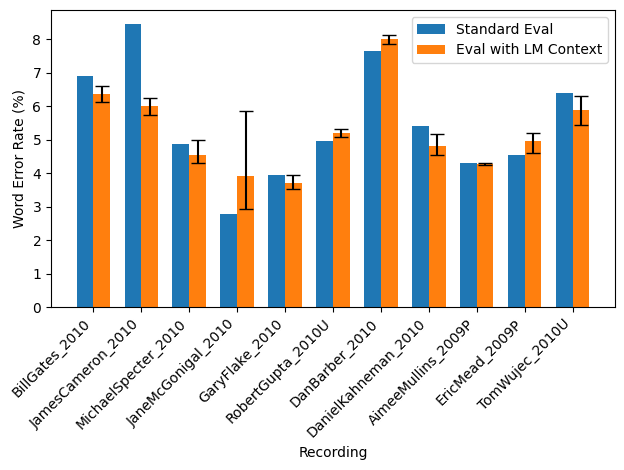

In [60]:
names = list(standard_eval_data['individual_wers'].keys())
standard_wers = [el * 100 for el in standard_eval_data['individual_wers'].values()]
lm_wers = [lm_context['individual_wers'][name] * 100 for name in names]
lm_wers_min = [lmc_min['individual_wers'][name] * 100 for name in names]
lm_wers_max = [lmc_max['individual_wers'][name] * 100 for name in names]
lm_lower_bound = [lm_wers[i] - lm_wers_min[i] for i in range(len(lm_wers))]
lm_upper_bound = [lm_wers_max[i] - lm_wers[i] for i in range(len(lm_wers))]
lm_errors = [lm_lower_bound, lm_upper_bound]

percent_decreases = [(standard - lm) / standard * 100 for standard, lm in zip(standard_wers, lm_wers)]

x = np.arange(len(names))  # the label locations
width = 0.35  # the width of the bars

# Plot side-by-side bars
plt.bar(x - width/2, standard_wers, width, label='Standard Eval')
plt.bar(x + width/2, lm_wers, width, label='Eval with LM Context', yerr=lm_errors, capsize=5)



# Labels and ticks
plt.xticks(x, names, rotation=45, ha='right')
plt.xlabel('Recording')
plt.ylabel('Word Error Rate (%)')
plt.legend()
plt.tight_layout()


plt.savefig('wer_comparison.pdf', bbox_inches='tight')

In [66]:
eval_with_LM_context_zero_epochs = torch.load('./qwen500m/tedlium-test.pt')
lm_context_6k = torch.load('./checkpoint-6k/tedlium-test.pt')
lm_context_5k = torch.load('./checkpoint-5k/tedlium-test.pt')
lm_context_4k = torch.load('./checkpoint-4k/tedlium-test.pt')
lm_context_3k = torch.load('./checkpoint-3k/tedlium-test.pt')
lm_context_2k = torch.load('./checkpoint-2k/tedlium-test.pt')


Text(0, 0.5, 'Word Error Rate (%)')

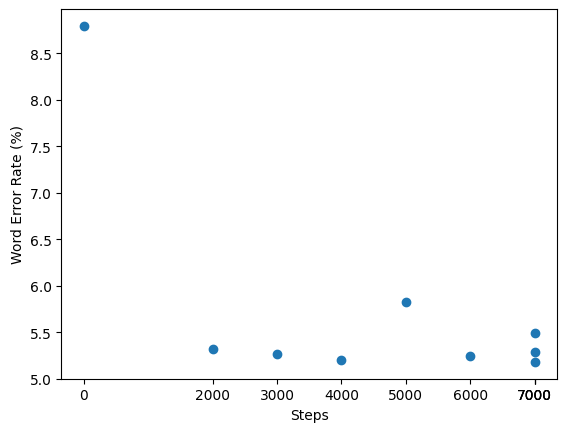

In [69]:
eval_with_LM_context_zero_epochs['wer']

steps = [0, 2000, 3000, 4000, 5000, 6000, 7000, 7000, 7000]
results = [eval_with_LM_context_zero_epochs['wer'], lm_context_2k['wer'], lm_context_3k['wer'], lm_context_4k['wer'], lm_context_5k['wer'], lm_context_6k['wer'], lm_context['wer'], lmc_min['wer'], lmc_max['wer']]

plt.scatter(steps, [el*100 for el in results], marker='o')
plt.xticks(steps)
plt.xlabel('Steps')
plt.ylabel('Word Error Rate (%)')
